In [1]:
import datetime
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go


In [2]:
def floor_to_day(dt: datetime.datetime) -> datetime.datetime:
  return dt.replace(hour=0, minute=0, second=0, microsecond=0)

In [3]:
def interactive_forecast_comparison(
    groundtruth: xr.Dataset,
    finetuned: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset,
    imd_tmax: xr.Dataset,
    imd_tmin: xr.Dataset,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Creates an interactive plot in Jupyter to compare two forecast datasets.

    Allows selecting variable, base time, and forecast step via widgets.

    Args:
        groundtruth (xr.Dataset): The first dataset (must contain coordinates
                          'base_time', 'step', 'latitude', 'longitude').
        finetuned (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset in plot titles.
        label2 (str): Label for the second dataset in plot titles.
    """

    required_coords = {'base_time', 'step', 'latitude', 'longitude'}
    # if not required_coords.issubset(groundtruth.coords) or not required_coords.issubset(finetuned.coords) or required_coords.issubset(forecasts.coords): # or required_coords.issubset(base.coords):
    #      print(f"Error: Datasets must contain coordinates: {required_coords}")
    #      return
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    finetuned = finetuned.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    imd_tmax = imd_tmax.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    imd_tmin = imd_tmin.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    
    common_vars = sorted(list(set(groundtruth.data_vars) & set(finetuned.data_vars)))
    # if not common_vars:
    #     print("Error: No common data variables found between the two datasets.")
    #     return

    variable_dropdown = widgets.Dropdown(
        options=common_vars,
        description='Variable:',
        style={'description_width': 'initial'}
    )

    base_time_options = sorted(groundtruth['base_time'].values)
    base_time_slider = widgets.SelectionSlider(
        options=[(pd.Timestamp(t).strftime('%Y-%m-%d %H:%M'), t) for t in base_time_options],
        description='Base Time:',
        style={'description_width': 'initial'},
        continuous_update=False
    )

    step_options = sorted(groundtruth['step'].values)
    step_slider = widgets.SelectionSlider(
        options=[(f"{int(pd.Timedelta(s).total_seconds() / 3600)} hr", s) for s in step_options],
        description='Step (Lead Time):',
        style={'description_width': 'initial'},
        continuous_update=False
    )

    # Output widget to display the plot
    plot_output = widgets.Output()

    # --- Plotting Function (called by widget changes) ---
    def update_plot(variable, base_time, step):
        """Selects data and creates the side-by-side plot."""
        with plot_output:
            clear_output(wait=True) # Clear previous plot

            # Select data slices - use .sel for label-based indexing
            data1 = groundtruth[variable].sel(base_time=base_time, step=step).load()
            data2 = finetuned[variable].sel(base_time=base_time, step=step).load()
            data3 = imd_tmax[variable].sel(base_time=base_time.astype('datetime64[D]')).load()
            data4 = base[variable].sel(base_time=base_time, step=step).load()
            data5 = forecasts[variable].sel(base_time=base_time, step=step).load()
            data6 = imd_tmin[variable].sel(base_time=base_time.astype('datetime64[D]')).load()
            # Determine common color limits for consistent comparison
            vmin = min(data1.min(), data2.min(), data3.min(), data4.min(), data5.min(), data6.min())
            vmax = max(data1.max(), data2.max(), data3.max(), data4.min(), data5.max(), data6.max())

            # Get units for colorbar label
            units = data1.attrs.get('units', '')
            cbar_label = f"{variable} ({units})" if units else variable

            # Create figure
            fig, axes = plt.subplots(2, 3, figsize=(10, 10), sharey=True, constrained_layout=True) # Share Y axis

            # Plot data 1
            plot1 = data1.plot(ax=axes[0][0], vmin=vmin, vmax=vmax, add_colorbar=False) # Add colorbar later
            axes[0][0].set_title(label1)

            # Plot data 2
            plot2 = data2.plot(ax=axes[0][1], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[0][1].set_title(label2)

            plot3 = data3.plot(ax=axes[0][2], vmin=vmin, vmax=vmax, add_colorbar=False) # Add colorbar later
            axes[0][2].set_title(label3)
            
            plot4 = data4.plot(ax=axes[1][0], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][0].set_title(label4)
            
            plot5 = data5.plot(ax=axes[1][1], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][1].set_title(label5)
            
            plot6 = data6.plot(ax=axes[1][2], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][2].set_title(label6)
            
            # Add a single colorbar for both plots
            fig.colorbar(plot2, ax=axes, label=cbar_label, aspect=30)

            # Add overall title
            valid_time = pd.Timestamp(base_time) + pd.Timedelta(step)
            fig.suptitle(f"Base: {pd.Timestamp(base_time).strftime('%Y-%m-%d %H:%M')}, "
                            f"Step: +{int(pd.Timedelta(step).total_seconds() / 3600)}h, "
                            f"Valid: {valid_time.strftime('%Y-%m-%d %H:%M')}",
                            y=1.02) # Adjust title position

            # plot1.tight_layout()
            # fig.tight_layout()
            # plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap
            plt.show()


    # --- Link Widgets to Plotting Function ---
    widgets.interactive_output(
        update_plot,
        {
            'variable': variable_dropdown,
            'base_time': base_time_slider,
            'step': step_slider
        }
    )

    # --- Display Widgets and Plot Output ---
    controls = widgets.VBox([variable_dropdown, base_time_slider, step_slider])
    display(controls, plot_output)

In [4]:
def interactive_error_plot(
    groundtruth: xr.Dataset,
    predicted: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset,
    imd_tmax: xr.Dataset,
    imd_tmin: xr.Dataset,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Creates an interactive plot in Jupyter showing the error (groundtruth - predicted)
    between two forecast datasets.

    Allows selecting variable, base time, and forecast step via widgets.

    Args:
        groundtruth (xr.Dataset): The first dataset.
        predicted (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset (used in title).
        label2 (str): Label for the second dataset (used in title).
    """
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    predicted = predicted.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    # imd_tmax = imd_tmax.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    # imd_tmin = imd_tmin.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    
    # Find common variables
    common_vars = sorted(list(set(groundtruth.data_vars) & set(predicted.data_vars) & set(base.data_vars) & set(forecasts.data_vars)))
    if not common_vars:
        print("Error: No common data variables found between the two datasets.")
        return

    # --- Create Widgets (same as comparison plot) ---
    variable_dropdown = widgets.Dropdown(options=common_vars, description='Variable:', style={'description_width': 'initial'})
    base_time_options = sorted(groundtruth['base_time'].values)
    base_time_slider = widgets.SelectionSlider(
        options=[(pd.Timestamp(t).strftime('%Y-%m-%d %H:%M'), t) for t in base_time_options],
        description='Base Time:', style={'description_width': 'initial'}, continuous_update=False
    )
    step_options = sorted(groundtruth['step'].values)
    step_slider = widgets.SelectionSlider(
        options=[(f"{int(pd.Timedelta(s).total_seconds() / 3600)} hr", s) for s in step_options],
        description='Step (Lead Time):', style={'description_width': 'initial'}, continuous_update=False
    )
    plot_output = widgets.Output()

    # --- Plotting Function (calculates and plots error) ---
    def update_error_plot(variable, base_time, step):
        """Selects data, calculates error, and creates the plot."""
        with plot_output:
            clear_output(wait=True) # Clear previous plot

            # Select data slices and calculate error
            data1 = groundtruth[variable].sel(base_time=base_time, step=step)
            data2 = predicted[variable].sel(base_time=base_time, step=step)
            data3 = base[variable].sel(base_time=base_time, step=step)
            data4 = forecasts[variable].sel(base_time=base_time, step=step)
            error_data = np.square((data2 - data1).load()) # Load data for plotting
            error_data2 = np.square((data3 - data1)).load()
            error_data3 = np.square((data4 - data1)).load()
            # Determine symmetric color limits centered at 0
            v_abs_max1 = np.abs(error_data).max()
            v_abs_max2 = np.abs(error_data2).max()
            v_abs_max = max(v_abs_max1, v_abs_max2)
            if v_abs_max == 0: # Handle case with zero error
                vmin, vmax = -1, 1 # Avoid zero range for colorbar
            else:
                vmin, vmax = -v_abs_max, v_abs_max

            # Get units for colorbar label
            units = data1.attrs.get('units', '')
            cbar_label = f"Error ({units})" if units else "Error"

            # Create figure with a single subplot
            fig, ax = plt.subplots(1, 3, figsize=(7, 5), sharey=True, constrained_layout=True)

            # Plot error data using a diverging colormap
            plot = error_data.plot(
                ax=ax[0],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            plot2 = error_data2.plot(
                ax=ax[1],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            plot3 = error_data3.plot(
                ax=ax[2],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            # Add title
            fig.colorbar(plot2, ax=ax, label=cbar_label, aspect=30)
            valid_time = pd.Timestamp(base_time) + pd.Timedelta(step)
            ax[0].set_title(label1)
            ax[1].set_title(label2)
            ax[2].set_title(label3)
            plt.suptitle(
                f"Errors for {variable}\n"
                f"Base: {pd.Timestamp(base_time).strftime('%Y-%m-%d %H:%M')}, "
                f"Step: +{int(pd.Timedelta(step).total_seconds() / 3600)}h, "
                f"Valid: {valid_time.strftime('%Y-%m-%d %H:%M')}"
            )

            # plt.tight_layout()
            plt.show()


    # --- Link Widgets to Plotting Function ---
    widgets.interactive_output(
        update_error_plot,
        {'variable': variable_dropdown, 'base_time': base_time_slider, 'step': step_slider}
    )

    # --- Display Widgets and Plot Output ---
    controls = widgets.VBox([variable_dropdown, base_time_slider, step_slider])
    display(controls, plot_output)


In [5]:
def plot_error_vs_lead_time(
    groundtruth: xr.Dataset,
    finetuned: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset = None,
    imd_tmax: xr.Dataset = None,
    imd_tmin: xr.Dataset = None,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Calculates and plots the Root Mean Squared Error (RMSE) between groundtruth and finetuned
    for each variable as a function of forecast lead time (step).

    Args:
        groundtruth (xr.Dataset): The first dataset.
        finetuned (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset (used in title).
        label2 (str): Label for the second dataset (used in title).
    """
     # --- Input Validation (Basic) ---
    if not isinstance(groundtruth, xr.Dataset) or not isinstance(finetuned, xr.Dataset):
        print("Error: Both groundtruth and finetuned must be xarray Datasets.")
        return
    # new_lats = np.linspace(-90, 90, 721)
    # new_lons = np.linspace(0, 359.75, 1440)
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    groundtruth = groundtruth.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    finetuned = finetuned.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    base = base.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 61), longitude=np.linspace(67.5, 97.5, 61))
    finetuned = finetuned.sel(latitude=np.linspace(7.5, 37.5, 61), longitude=np.linspace(67.5, 97.5, 61))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 61), longitude=np.linspace(67.5, 97.5, 61))
    fore = False
    if forecasts is not None:
        fore = True
        forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 61), longitude=np.linspace(67.5, 97.5, 61))
        forecasts = forecasts.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    
    # Calculate error dataset
    try:
        # Ensure datasets are aligned for subtraction
        finetuned_aligned, groundtruth_aligned = xr.align(finetuned, groundtruth, join='inner')
        error_ds = groundtruth_aligned - finetuned_aligned
        base_aligned, groundtruth_aligned = xr.align(base, groundtruth, join='inner')
        error_ds2 = groundtruth_aligned - base_aligned
        if fore:
            fore_aligned, groundtruth_aligned = xr.align(forecasts, groundtruth, join='inner')
            error_ds3 = groundtruth_aligned - fore_aligned
    except Exception as e:
        print(f"Error aligning or subtracting datasets: {e}")
        return

    common_vars = sorted(list(error_ds.data_vars))
    if not common_vars:
        print("Error: No common data variables found after alignment.")
        return

    print("Calculating RMSE vs. Lead Time...")

    # Calculate RMSE for each variable, grouped by step
    # RMSE = sqrt(mean(error^2)) averaged over base_time, latitude, longitude
    def rmse_func(x):
      # Ensure input is treated as float for calculations
      squared_error = (x.astype(float)**2)
      # Mean calculation skipping NaNs
      mean_squared_error = squared_error.mean(dim=['base_time', 'latitude', 'longitude'], skipna=True)
      # Calculate sqrt, handle potential NaNs from mean if all inputs were NaN
      rmse = np.sqrt(mean_squared_error)
      return rmse

    # Apply the function to each variable grouped by step
    try:
        # Apply the function using map which handles DataArrays within the Dataset
        rmse_vs_step = error_ds.groupby('step').map(rmse_func)
        rmse_vs_step2 = error_ds2.groupby('step').map(rmse_func)
        # Ensure computation happens if results are dask arrays
        rmse_vs_step = rmse_vs_step.compute()
        rmse_vs_step2 = rmse_vs_step2.compute()
        if fore:
            rmse_vs_step3 = error_ds3.groupby('step').map(rmse_func)
            rmse_vs_step3 = rmse_vs_step3.compute()
    except Exception as e:
        print(f"Error calculating RMSE using groupby.map: {e}")
        # Fallback: Loop over variables if groupby fails (less efficient)
        rmse_results = {}
        rmse_results2 = {}
        rmse_results3 = {}
        for var in common_vars:
            print(f"  Processing variable: {var} (Fallback method)")
            try:
                # Apply to each variable's DataArray individually
                rmse_da = error_ds[var].groupby('step').apply(rmse_func).compute()
                rmse_results[var] = rmse_da
                rmse_da2 = error_ds2[var].groupby('step').apply(rmse_func).compute()
                rmse_results2[var] = rmse_da2
                if fore:
                    rmse_da3 = error_ds3[var].groupby('step').apply(rmse_func).compute()
                    rmse_results2[var] = rmse_da3                
            except Exception as e_var:
                print(f"  Could not calculate RMSE for variable '{var}': {e_var}")
        if not rmse_results:
            print("Error: Could not calculate RMSE for any variable.")
            return # Stop if no variables could be processed
        rmse_vs_step = xr.Dataset(rmse_results)
        rmse_vs_step2 = xr.Dataset(rmse_results2)
        if fore:
            rmse_vs_step3 = xr.Dataset(rmse_results3)
    # Get lead times in hours for plotting
    lead_times_hours = rmse_vs_step['step'].dt.total_seconds() / 3600

    # Create a plot for each variable
    print("Plotting RMSE vs. Lead Time...")
    for var in rmse_vs_step.data_vars:
        plt.figure(figsize=(8, 5))
        # Attempt to get units from the original dataset's attributes
        units = groundtruth_aligned[var].attrs.get('units', '') # Use aligned dataset
        rmse_values = rmse_vs_step[var]
        rmse_values2 = rmse_vs_step2[var]
        if fore:
            rmse_values3 = rmse_vs_step3[var]

        # Check if rmse_values contains any non-NaN data before plotting
        if not rmse_values.isnull().all():
            plt.plot(lead_times_hours, rmse_values, marker='o', linestyle='-', label=label1, color='blue')
            plt.plot(lead_times_hours, rmse_values2, marker='o', linestyle='-', label=label2, color='orange')
            if fore:
                plt.plot(lead_times_hours, rmse_values3, marker='o', linestyle='-', label=label3, color='green')
            plt.xlabel("Lead Time (hours)")
            plt.ylabel(f"RMSE ({units})" if units else "RMSE")
            plt.title(f"RMSE ({label1} vs {label2}) for {var} vs. Lead Time")
            plt.grid(True)
            # Ensure x-ticks cover the range of lead times nicely
            plt.xticks(np.unique(lead_times_hours.round(1))) # Use unique rounded hours
            plt.xlim(left=lead_times_hours.min() - (lead_times_hours.max() - lead_times_hours.min())*0.05, # Add padding
                     right=lead_times_hours.max() + (lead_times_hours.max() - lead_times_hours.min())*0.05)
            # plt.ylim(bottom=0) # RMSE cannot be negative
            plt.legend()
            plt.tight_layout()
            
            # plt.subplot(1, 2, 1)
            # plt.xlabel("Lead Time (hours)")
            # plt.ylabel(f"RMSE ({units})" if units else "RMSE")
            # plt.title(f"RMSE ({label1} vs {label2}) for {var} vs. Lead Time")
            # plt.grid(True)
            # # Ensure x-ticks cover the range of lead times nicely
            # plt.xticks(np.unique(lead_times_hours.round(1))) # Use unique rounded hours
            # plt.xlim(left=lead_times_hours.min() - (lead_times_hours.max() - lead_times_hours.min())*0.05, # Add padding
            #          right=lead_times_hours.max() + (lead_times_hours.max() - lead_times_hours.min())*0.05)
            # plt.ylim(bottom=0) # RMSE cannot be negative
            # plt.tight_layout()
            
            plt.show()
        else:
            print(f"  Skipping plot for variable '{var}': All RMSE values are NaN.")

In [6]:
def filter_dates(ds, start_date="2022-01-01", end_date="2023-01-01", midnight=False):
    base_times = pd.to_datetime(ds['base_time'].values)
    if midnight:
        mask = ((base_times.time == pd.to_datetime("00:00").time()) | (base_times.time == pd.to_datetime("12:00").time())) & \
                        (base_times >= pd.to_datetime(start_date)) & \
                        (base_times <= pd.to_datetime(end_date))
        return ds.sel(base_time=base_times[mask])
    else:
        mask = (base_times >= pd.to_datetime(start_date)) & \
                (base_times <= pd.to_datetime(end_date))
        return ds.sel(base_time=base_times[mask])

In [7]:
import imdlib as imdl
tmax_data = imdl.open_data('tmax', 2022, 2023,'yearwise', 'tmax')
tmin_data = imdl.open_data('tmin', 2022, 2023,'yearwise', 'tmin')

In [8]:
tmax_data = tmax_data.get_xarray()
tmin_data = tmin_data.get_xarray()

In [9]:
tmax_data = tmax_data.rename({'time': 'base_time', 'tmax': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
tmin_data = tmin_data.rename({'time': 'base_time', 'tmin': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
threshold = 54

tmax_data['2m_temperature'] = tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold, tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold).mean())
tmin_data['2m_temperature'] = tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold, tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold).mean())

tmax_data['2m_temperature'] += 273.15
tmin_data['2m_temperature'] += 273.15

In [10]:
groundtruth = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')
groundtruth.coords['step'] = groundtruth.coords['step'] + pd.to_timedelta(6, unit='h')
groundtruth_filtered = filter_dates(groundtruth)

predictions = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted.zarr')
predictions.coords['step'] = predictions.coords['step'] + pd.to_timedelta(6, unit='h')
predictions_filtered = filter_dates(predictions)

base = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted_base.zarr')
base.coords['step'] = base.coords['step'] + pd.to_timedelta(6, unit='h')
base_filtered = filter_dates(base)

imd = xr.load_dataset('/Datastorage/divij.khaitan_asp25/forecasts_2022/imd_forecasts.nc')
rename_dict = {'time': 'base_time', 't2m': '2m_temperature', 'tp': 'total_precipitation'}

imd = imd.rename(rename_dict)

ncep = xr.load_dataset('/Datastorage/divij.khaitan_asp25/forecasts_2022/ncep_forecasts.nc')
rename_dict = {'time': 'base_time', 't2m': '2m_temperature', 'tp': 'total_precipitation'}

ncep = ncep.rename(rename_dict)

coords_to_drop = ['number', 'heightAboveGround', 'surface', 'valid_time']
coords_to_drop = [coord for coord in coords_to_drop if coord in ncep.coords]
if coords_to_drop:
    ncep = ncep.drop_vars(coords_to_drop)
    imd = imd.drop_vars(coords_to_drop)
ncep_filtered = filter_dates(ncep)
imd_filtered = filter_dates(imd)
tmax_filtered = filter_dates(tmax_data)
tmin_filtered = filter_dates(tmin_data)



/tmp/ipykernel_3415610/1337416744.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  groundtruth = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')
/tmp/ipykernel_3415610/1337416744.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted.zarr')
/tmp/ipykernel_3415610/1337416744.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  base = xr.open_zarr('/Datastorage/divij.khaita

In [11]:
interactive_forecast_comparison(groundtruth, predictions, base, ncep, tmax_data, tmin_data, label5='NCEP Forecast')
# interactive_forecast_comparison(groundtruth_filtered, predictions_filtered, base_filtered, imd, tmax_filtered, tmin_filtered)

Output()

In [ ]:
interactive_forecast_comparison(groundtruth_filtered, predictions_filtered, base_filtered, imd_filtered, tmax_filtered, tmin_filtered)

Output()

In [13]:
interactive_error_plot(groundtruth_filtered, predictions_filtered, base_filtered, ncep_filtered, tmax_filtered, tmin_filtered, 'ERA5-Finetuned', 'Base', 'NCEP Forecast')

Output()

In [14]:
interactive_error_plot(groundtruth_filtered, predictions_filtered, base_filtered, imd_filtered, tmax_filtered, tmin_filtered, 'ERA5-Finetuned', 'Base', 'NCEP Forecast')

Output()

Calculating RMSE vs. Lead Time...
Plotting RMSE vs. Lead Time...


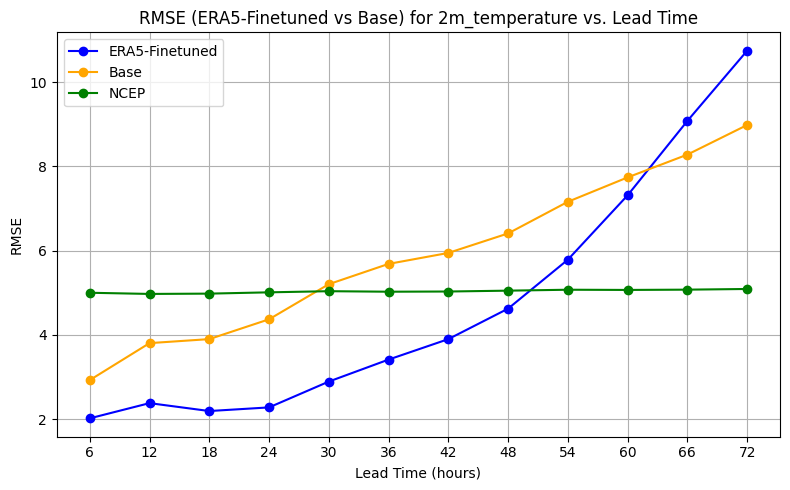

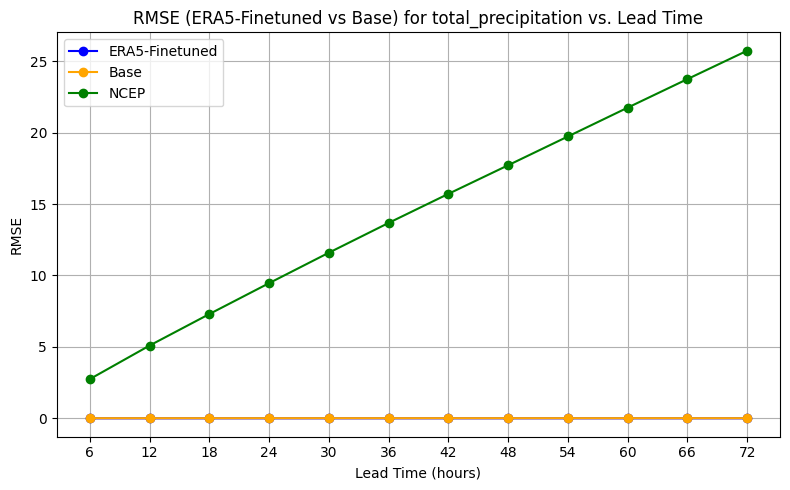

In [15]:
plot_error_vs_lead_time(groundtruth, predictions, base, ncep, label1='ERA5-Finetuned', label2='Base', label3='NCEP')

Calculating RMSE vs. Lead Time...
Plotting RMSE vs. Lead Time...


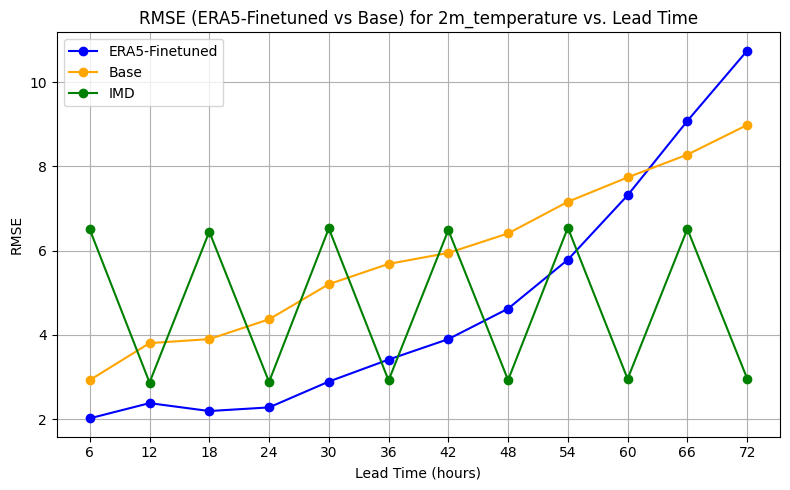

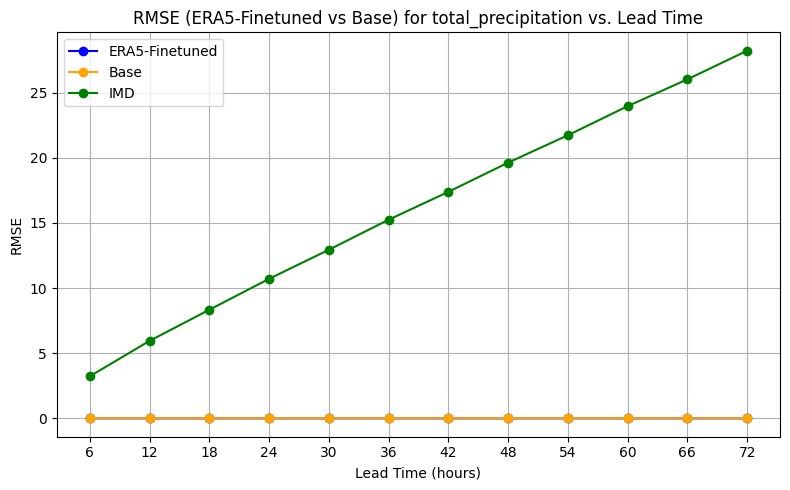

In [16]:
plot_error_vs_lead_time(groundtruth_filtered, predictions_filtered, base_filtered, imd_filtered, label1='ERA5-Finetuned', label2='Base', label3='IMD')

In [17]:
def compute_spatial_average(ds, variable_name, use_latitude_weights=True):
    """
    Computes the spatial average of a variable in an xarray.Dataset.
    """
    # print(ds)
    if use_latitude_weights:
        weights = np.cos(np.deg2rad(ds.latitude))
        weights = weights / weights.mean() 
        spatial_avg = ds[variable_name].weighted(weights).mean(dim=["latitude", "longitude"])
    else:
        spatial_avg = ds[variable_name].mean(dim=["latitude", "longitude"])
    return spatial_avg

def plot_interactive_forecast_comparison_ts(
    ground_truth_ds,
    forecast_datasets, 
    variable_name,
    use_latitude_weights_for_avg=True
):
    """
    Generates an interactive plot using ipywidgets and Plotly FigureWidget.
    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot.
        use_latitude_weights_for_avg (bool): Latitude weighting for spatial average.
    Returns:
        ipywidgets.VBox: A VBox containing the dropdown and the plot.
    """
    
    # Use FigureWidget for compatibility with ipywidgets
    fig_widget = go.FigureWidget()
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    ground_truth_ds = ground_truth_ds.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    for key, _ in forecast_datasets.items():
        forecast_datasets[key] = forecast_datasets[key].interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    
    # Process and plot ground truth 
    if 'step' in ground_truth_ds.coords and len(ground_truth_ds.step) > 0:
        reference_step = ground_truth_ds.step.min().item()
        reference_step = pd.to_timedelta(reference_step)
        gt_selected_step_ds = ground_truth_ds.sel(step=reference_step)
        gt_spatial_avg = compute_spatial_average(gt_selected_step_ds, variable_name, use_latitude_weights_for_avg)
        gt_x_values = gt_selected_step_ds.base_time.data + reference_step
        gt_y_values = gt_spatial_avg.data
    elif 'time' in ground_truth_ds.coords:
        gt_spatial_avg = compute_spatial_average(ground_truth_ds, variable_name, use_latitude_weights_for_avg)
        gt_x_values = gt_spatial_avg.time.data 
        gt_y_values = gt_spatial_avg.data
    else:
        raise ValueError("Ground truth dataset must have 'step' or 'time' coordinate.")

    fig_widget.add_trace(go.Scatter(
        x=gt_x_values,
        y=gt_y_values,
        mode='lines+markers',
        name='Ground Truth',
        line=dict(color='black', width=2, dash='dash')
    ))

    all_steps_values = np.array([])
    step_options_for_dropdown = []

    if forecast_datasets:
        first_forecast_name = list(forecast_datasets.keys())[0]
        if 'step' in forecast_datasets[first_forecast_name].coords:
            all_steps_values = np.sort(np.unique(forecast_datasets[first_forecast_name].step.data))
            step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]

    # Pre-calculate all spatial averages for forecasts
    precomputed_forecast_spatial_avgs = {}
    if forecast_datasets:
        for model_name, ds_forecast in forecast_datasets.items():
            precomputed_forecast_spatial_avgs[model_name] = compute_spatial_average(
                ds_forecast, variable_name, use_latitude_weights_for_avg
            )

    # Add initial traces for each forecast model (for the first step)
    initial_step_value = all_steps_values[0] if len(all_steps_values) > 0 else None
    
    forecast_traces_indices = [] # To keep track of which traces belong to forecasts
    
    for model_idx, (model_name, ds_forecast) in enumerate(forecast_datasets.items()):
        x_init, y_init = [], []
        if initial_step_value is not None and model_name in precomputed_forecast_spatial_avgs:
            forecast_spatial_avg = precomputed_forecast_spatial_avgs[model_name]
            selected_step_data_array = forecast_spatial_avg.sel(step=initial_step_value)
            valid_times_for_plot = selected_step_data_array.coords['base_time'].data + initial_step_value
            x_init = valid_times_for_plot
            y_init = selected_step_data_array.data
        
        fig_widget.add_trace(go.Scatter(
            x=x_init,
            y=y_init,
            mode='lines',
            name=f'{model_name}'
        ))
        forecast_traces_indices.append(model_idx + 1) # +1 because GT is trace 0

    # Create ipywidgets.Dropdown for step selection
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value if initial_step_value is not None else None,
        description='Lead Time:',
        disabled=not bool(step_options_for_dropdown) # Disable if no steps
    )

    # Define the function to update plot on dropdown change
    def update_plot_on_step_change(change):
        selected_step_val = change['new'] # The new value of the dropdown
        
        with fig_widget.batch_update(): # Efficiently update multiple traces
            for i, model_name_iter in enumerate(forecast_datasets.keys()):
                trace_idx = forecast_traces_indices[i] # Get the correct trace index
                if model_name_iter in precomputed_forecast_spatial_avgs:
                    forecast_spatial_avg = precomputed_forecast_spatial_avgs[model_name_iter]
                    
                    # Check if the selected step exists for this model's precomputed avg
                    if selected_step_val in forecast_spatial_avg.step.data:
                        selected_step_data_array = forecast_spatial_avg.sel(step=selected_step_val)
                        valid_times_for_plot = selected_step_data_array.coords['base_time'].data + selected_step_val
                        
                        fig_widget.data[trace_idx].x = valid_times_for_plot
                        fig_widget.data[trace_idx].y = selected_step_data_array.data
                    else: # If step not available (e.g. different models have different steps)
                        fig_widget.data[trace_idx].x = []
                        fig_widget.data[trace_idx].y = []
                else:
                    fig_widget.data[trace_idx].x = []
                    fig_widget.data[trace_idx].y = []

    step_dropdown.observe(update_plot_on_step_change, names='value')

    # Configure plot layout
    fig_title = f'Spatially Averaged {variable_name.replace("_", " ").title()} Comparison'
    yaxis_title = f'{variable_name.replace("_", " ").title()}'
    if variable_name == "2m_temperature":
        yaxis_title += " (K)"
    elif variable_name == "total_precipitation":
        yaxis_title += " (mm)"

    fig_widget.update_layout(
        title=fig_title,
        xaxis_title='Valid Time',
        yaxis_title=yaxis_title,
        legend_title_text='Legend',
        hovermode="x unified"
    )
    
    # Return a VBox containing the dropdown and the FigureWidget
    return widgets.VBox([step_dropdown, fig_widget])

In [18]:
def compute_spatial_average_of_field(field_da, use_latitude_weights=True):
    """
    Computes the spatial average of a DataArray (e.g., an error field).
    Assumes field_da has 'latitude' and 'longitude' dimensions.
    """
    if not field_da.chunks: # Ensure it's not a dask array without chunks for weighted
        field_da = field_da.compute() # Load into memory if it's a small result

    if use_latitude_weights:
        weights = np.cos(np.deg2rad(field_da.latitude))
        weights = weights / weights.mean() 
        # Ensure weights are aligned if field_da is chunked
        # weights = weights.chunk({'latitude': field_da.chunks['latitude']}) if field_da.chunks else weights
        spatial_avg = field_da.weighted(weights).mean(dim=["latitude", "longitude"])
    else:
        spatial_avg = field_da.mean(dim=["latitude", "longitude"])
    return spatial_avg

def plot_interactive_daily_error_comparison(
    ground_truth_ds,
    forecast_datasets, 
    variable_name,
    use_latitude_weights_for_avg=True
):
    """
    Generates an interactive plot of spatially averaged errors of daily maxima and minima 
    using ipywidgets and Plotly FigureWidget.
    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot.
        use_latitude_weights_for_avg (bool): Latitude weighting for spatial average of errors.
    Returns:
        ipywidgets.VBox: A VBox containing the dropdown and the plot.
    """
    
    fig_widget = go.FigureWidget()
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    ground_truth_ds = ground_truth_ds.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    for key, _ in forecast_datasets.items():
        forecast_datasets[key] = forecast_datasets[key].interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    # --- Process Ground Truth: Get Gridded Daily Max/Min ---
    reference_step = pd.to_timedelta('0 hours') 
    if 'step' in ground_truth_ds.coords and len(ground_truth_ds.step) > 0:
        reference_step = pd.to_timedelta(ground_truth_ds.step.min().item())
        gt_data_at_ref_step = ground_truth_ds[variable_name].sel(step=reference_step)
    elif 'time' in ground_truth_ds.coords: # Observational data
        # Ensure 'time' coord is named 'base_time' for consistency with resample
        if 'base_time' not in ground_truth_ds[variable_name].coords:
            gt_data_at_ref_step = ground_truth_ds[variable_name].rename({'time': 'base_time'})
        else:
            gt_data_at_ref_step = ground_truth_ds[variable_name]
    else:
        raise ValueError("Ground truth dataset must have 'step' or 'time' coordinate.")

    # Resample GT to daily max/min at each grid point
    # The 'base_time' coordinate of these will be daily.
    gt_daily_max_gridded = gt_data_at_ref_step.resample(base_time="1D").max()
    gt_daily_min_gridded = gt_data_at_ref_step.resample(base_time="1D").min()

    # --- Pre-calculate Gridded Daily Max/Min for Forecasts ---
    precomputed_fcst_daily_max_gridded = {}
    precomputed_fcst_daily_min_gridded = {}
    
    all_steps_values = np.array([])
    if forecast_datasets:
        first_forecast_name = list(forecast_datasets.keys())[0] # Assume steps are consistent
        if 'step' in forecast_datasets[first_forecast_name].coords:
            all_steps_values = np.sort(np.unique(forecast_datasets[first_forecast_name].step.data))

        for model_name, ds_forecast in forecast_datasets.items():
            model_var_data = ds_forecast[variable_name] # This has (base_time, step, lat, lon)
            # Resample over base_time for each step, lat, lon to get daily values
            precomputed_fcst_daily_max_gridded[model_name] = model_var_data.resample(base_time="1D").max()
            precomputed_fcst_daily_min_gridded[model_name] = model_var_data.resample(base_time="1D").min()
    
    step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]

    # --- Add Initial Traces for Forecast Errors (Daily Max & Min MAE) ---
    initial_step_value = all_steps_values[0] if len(all_steps_values) > 0 else None
    initial_step_value = pd.Timedelta(all_steps_values[0]) if len(all_steps_values) > 0 else pd.Timedelta('0 hours')

    # Store trace indices: each model will have a max error trace and a min error trace
    # e.g., { 'Model A': {'max_trace_idx': 0, 'min_trace_idx': 1}, ... }
    model_trace_indices = {} 
    current_trace_idx = 0

    if initial_step_value is not None:
        for model_name in forecast_datasets.keys():
            fcst_daily_max_at_step = precomputed_fcst_daily_max_gridded[model_name].sel(step=initial_step_value)
            fcst_daily_min_at_step = precomputed_fcst_daily_min_gridded[model_name].sel(step=initial_step_value)

            # Align with GT and calculate error (Xarray handles alignment based on coords)
            error_daily_max_gridded = fcst_daily_max_at_step - gt_daily_max_gridded
            error_daily_min_gridded = fcst_daily_min_at_step - gt_daily_min_gridded
            
            # Calculate Mean Absolute Error (MAE) time series
            mae_daily_max_ts = compute_spatial_average_of_field(np.abs(error_daily_max_gridded), use_latitude_weights_for_avg)
            mae_daily_min_ts = compute_spatial_average_of_field(np.abs(error_daily_min_gridded), use_latitude_weights_for_avg)
            
            # Valid times for the x-axis of the error plot
            # The base_time of mae_daily_max_ts is daily (from resample)
            # Add the selected step to get the valid time of the daily statistic
            x_plot_valid_time = mae_daily_max_ts.base_time.data + initial_step_value

            fig_widget.add_trace(go.Scatter(
                x=x_plot_valid_time, y=mae_daily_max_ts.data, mode='lines', 
                name=f'{model_name} (MAE Daily Max)'
            ))
            model_trace_indices[model_name] = {'max_trace_idx': current_trace_idx}
            current_trace_idx += 1

            fig_widget.add_trace(go.Scatter(
                x=x_plot_valid_time, y=mae_daily_min_ts.data, mode='lines', 
                name=f'{model_name} (MAE Daily Min)', line=dict(dash='dash')
            ))
            model_trace_indices[model_name]['min_trace_idx'] = current_trace_idx
            current_trace_idx += 1

    # --- Create ipywidgets.Dropdown for step selection ---
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value,
        description='Lead Time:',
        disabled=not bool(step_options_for_dropdown)
    )

    # --- Define the function to update plot on dropdown change ---
    def update_plot_on_step_change(change):
        selected_step_val = change['new'] 
        
        with fig_widget.batch_update():
            for model_name in forecast_datasets.keys():
                if model_name not in precomputed_fcst_daily_max_gridded: continue

                fcst_daily_max_at_step = precomputed_fcst_daily_max_gridded[model_name].sel(step=selected_step_val)
                fcst_daily_min_at_step = precomputed_fcst_daily_min_gridded[model_name].sel(step=selected_step_val)

                error_daily_max_gridded = fcst_daily_max_at_step - gt_daily_max_gridded
                error_daily_min_gridded = fcst_daily_min_at_step - gt_daily_min_gridded
                
                mae_daily_max_ts = compute_spatial_average_of_field(np.abs(error_daily_max_gridded), use_latitude_weights_for_avg)
                mae_daily_min_ts = compute_spatial_average_of_field(np.abs(error_daily_min_gridded), use_latitude_weights_for_avg)
                
                x_plot_valid_time = mae_daily_max_ts.base_time.data + selected_step_val
                
                # Update traces
                max_idx = model_trace_indices[model_name]['max_trace_idx']
                min_idx = model_trace_indices[model_name]['min_trace_idx']

                fig_widget.data[max_idx].x = x_plot_valid_time
                fig_widget.data[max_idx].y = mae_daily_max_ts.data
                
                fig_widget.data[min_idx].x = x_plot_valid_time
                fig_widget.data[min_idx].y = mae_daily_min_ts.data
                
    step_dropdown.observe(update_plot_on_step_change, names='value')

    # --- Configure plot layout ---
    fig_title = f'Spatially Averaged MAE of Daily Max/Min {variable_name.replace("_", " ").title()}'
    yaxis_title = f'Mean Absolute Error ({variable_name.replace("_", " ").title()})'
    if variable_name == "2m_temperature":
        yaxis_title += " (K)"
    elif variable_name == "total_precipitation":
        yaxis_title += " (mm)" # Or appropriate unit for precipitation error

    fig_widget.update_layout(
        title=fig_title,
        xaxis_title='Valid Time of Daily Statistic',
        yaxis_title=yaxis_title,
        legend_title_text='Model Error',
        hovermode="x unified"
    )
    
    return widgets.VBox([step_dropdown, fig_widget])

In [19]:
# def plot_interactive_timeseries_at_grid(
#     ground_truth_ds,
#     forecast_datasets,
#     variable_name="2m_temperature"
# ):
#     """
#     Generates an interactive plot to visualize time series of a variable (e.g., 2m_temperature)
#     at a specific chosen grid point, comparing all datasets.
#     Allows interactive selection of latitude, longitude, forecast lead time (step), and time range.

#     Args:
#         ground_truth_ds (xr.Dataset): Dataset for ground truth.
#         forecast_datasets (dict): Dictionary of forecast datasets.
#         variable_name (str): The variable to plot (default: "2m_temperature").
#     Returns:
#         ipywidgets.VBox: A VBox containing the dropdowns, sliders, and the plot.
#     """

#     fig_widget = go.FigureWidget()

#     # Create a unified dictionary of all datasets for easier selection
#     all_datasets = {"Ground Truth": ground_truth_ds}
#     all_datasets.update(forecast_datasets)

#     # --- Pre-process datasets for common coordinates and interpolation ---
#     # Determine the common base_time range across all datasets
#     global_min_base_time = pd.Timestamp.max
#     global_max_base_time = pd.Timestamp.min

#     for ds_name, ds in all_datasets.items():
#         # Ensure 'time' is renamed to 'base_time' if it exists
#         if 'time' in ds.coords and 'base_time' not in ds.coords:
#             all_datasets[ds_name] = ds.rename({'time': 'base_time'})
        
#         if 'base_time' in all_datasets[ds_name].coords:
#             current_min_time = pd.Timestamp(all_datasets[ds_name].base_time.min().item())
#             current_max_time = pd.Timestamp(all_datasets[ds_name].base_time.max().item())
#             global_min_base_time = min(global_min_base_time, current_min_time)
#             global_max_base_time = max(global_max_base_time, current_max_time)
#         else:
#             raise ValueError(f"Dataset '{ds_name}' must have 'step' or 'time' coordinate, or 'base_time'.")

#     # Define common lat/lon grid for interpolation
#     # These will be the options for the latitude/longitude dropdowns
#     common_lats = np.linspace(7.5, 37.5, 61)
#     common_lons = np.linspace(67.5, 97.5, 61)

#     # Store interpolated DataArrays for selected variable for efficiency
#     interpolated_var_data = {}
#     for ds_name, ds in all_datasets.items():
#         interpolated_var_data[ds_name] = ds[variable_name].interp(
#             {'latitude': common_lats, 'longitude': common_lons},
#             method='linear',
#             kwargs={'fill_value': None}
#         )

#     # --- Get all unique steps from forecast datasets ---
#     all_steps_values = []
#     for model_name, ds_forecast in forecast_datasets.items():
#         if 'step' in ds_forecast.coords:
#             all_steps_values.extend(ds_forecast.step.data)
#     all_steps_values = np.sort(np.unique(all_steps_values))
    
#     # Step options for dropdown including 'Ground Truth' as 0 hr lead
#     step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]
#     step_options_for_dropdown.insert(0, ("Ground Truth (0 hr lead)", pd.Timedelta('0 hours'))) # Add GT as a default

#     # --- Create ipywidgets for selection ---
#     # Latitude and Longitude dropdowns
#     latitude_options = [(f"{lat:.2f}°N", lat) for lat in common_lats]
#     longitude_options = [(f"{lon:.2f}°E", lon) for lon in common_lons]

#     # Set initial lat/lon to roughly center of the domain, or first available
#     initial_lat = common_lats[len(common_lats) // 2]
#     initial_lon = common_lons[len(common_lons) // 2]

#     latitude_dropdown = widgets.Dropdown(
#         options=latitude_options,
#         value=initial_lat,
#         description='Latitude:',
#     )

#     longitude_dropdown = widgets.Dropdown(
#         options=longitude_options,
#         value=initial_lon,
#         description='Longitude:',
#     )

#     # Lead Time (Step) dropdown
#     # initial_step_value = all_steps_values[0] if len(all_steps_values) > 0 else pd.Timedelta('0 hours') # Default to first forecast lead or 0hr
#     initial_step_value = pd.Timedelta(all_steps_values[0]) if len(all_steps_values) > 0 else pd.Timedelta('0 hours')

#     step_dropdown = widgets.Dropdown(
#         options=step_options_for_dropdown,
#         value=initial_step_value,
#         description='Forecast Lead:',
#         disabled=not bool(step_options_for_dropdown)
#     )

#     # Date Pickers for Time Range
#     min_date_for_picker = global_min_base_time.to_pydatetime().date()
#     max_date_for_picker = global_max_base_time.to_pydatetime().date()

#     start_date_picker = widgets.DatePicker(
#         description='Start Date:',
#         value=min_date_for_picker,
#         min=min_date_for_picker,
#         max=max_date_for_picker,
#         disabled=False
#     )

#     end_date_picker = widgets.DatePicker(
#         description='End Date:',
#         value=max_date_for_picker,
#         min=min_date_for_picker,
#         max=max_date_for_picker,
#         disabled=False
#     )

#     # --- Define the update function for the plot ---
#     def update_plot_timeseries(*args): # Accepts any number of arguments from observe
#         selected_lat = latitude_dropdown.value
#         selected_lon = longitude_dropdown.value
#         selected_step = step_dropdown.value
#         start_date = start_date_picker.value
#         end_date = end_date_picker.value

#         start_ts_filter = pd.Timestamp(start_date)
#         end_ts_filter = pd.Timestamp(end_date) + pd.Timedelta('1D') - pd.Timedelta('1ns') # Include full end day

#         with fig_widget.batch_update():
#             fig_widget.data = [] # Clear previous traces

#             current_y_min = np.inf
#             current_y_max = -np.inf

#             # Plot Ground Truth first (always 0 hr lead)
#             gt_data_at_point = interpolated_var_data["Ground Truth"].sel(
#                 latitude=selected_lat, longitude=selected_lon, method='nearest'
#             )
#             # Filter by date range
#             gt_data_filtered = gt_data_at_point.sel(base_time=slice(start_ts_filter, end_ts_filter))
            
#             if gt_data_filtered.size > 0:
#                 fig_widget.add_trace(go.Scatter(
#                     x=gt_data_filtered.base_time.data,
#                     y=gt_data_filtered.data,
#                     mode='lines',
#                     name=f'Ground Truth'
#                 ))
#                 current_y_min = min(current_y_min, np.nanmin(gt_data_filtered.data) if gt_data_filtered.size > 0 else np.inf)
#                 current_y_max = max(current_y_max, np.nanmax(gt_data_filtered.data) if gt_data_filtered.size > 0 else -np.inf)

#             # Plot Forecasts
#             for model_name, model_da in interpolated_var_data.items():
#                 if model_name == "Ground Truth":
#                     continue # Already plotted

#                 # Select data for the specific lat/lon and lead time
#                 model_data_at_point_step = model_da.sel(
#                     latitude=selected_lat, longitude=selected_lon, step=selected_step, method='nearest'
#                 )
                
#                 # Calculate valid_time (base_time + step)
#                 valid_time = model_data_at_point_step.base_time.data + selected_step
                
#                 # Create a DataArray for easier filtering with valid_time as coordinate
#                 # This ensures valid_time is a proper coordinate for slicing
#                 ts_data = xr.DataArray(
#                     model_data_at_point_step.data,
#                     coords={'valid_time': valid_time},
#                     dims=['valid_time']
#                 )

#                 # Filter by date range
#                 ts_data_filtered = ts_data.sel(valid_time=slice(start_ts_filter, end_ts_filter))

#                 if ts_data_filtered.size > 0:
#                     fig_widget.add_trace(go.Scatter(
#                         x=ts_data_filtered.valid_time.data,
#                         y=ts_data_filtered.data,
#                         mode='lines',
#                         name=f'{model_name} ({int(selected_step / np.timedelta64(1, "h"))} hr lead)'
#                     ))
#                     current_y_min = min(current_y_min, np.nanmin(ts_data_filtered.data) if ts_data_filtered.size > 0 else np.inf)
#                     current_y_max = max(current_y_max, np.nanmax(ts_data_filtered.data) if ts_data_filtered.size > 0 else -np.inf)

#             # Configure plot layout
#             plot_title = (
#                 f'Time Series of {variable_name.replace("_", " ").title()} at '
#                 f'Lat: {selected_lat:.2f}°N, Lon: {selected_lon:.2f}°E'
#             )
#             yaxis_title = f'{variable_name.replace("_", " ").title()}'
#             if variable_name == "2m_temperature":
#                 yaxis_title += " (K)"
#             elif variable_name == "total_precipitation":
#                 yaxis_title += " (mm)"

#             fig_widget.update_layout(
#                 title=plot_title,
#                 xaxis_title='Valid Time',
#                 yaxis_title=yaxis_title,
#                 legend_title_text='Dataset / Lead Time',
#                 hovermode="x unified",
#                 xaxis_type='date'
#             )

#             # Adjust y-axis range if data exists
#             if current_y_min != np.inf and current_y_max != -np.inf:
#                 # Add some padding to the y-axis
#                 padding = (current_y_max - current_y_min) * 0.05
#                 fig_widget.update_yaxes(range=[current_y_min - padding, current_y_max + padding])
#             else:
#                 fig_widget.update_layout(title_text=f"No data available for Lat: {selected_lat:.2f}°N, Lon: {selected_lon:.2f}°E in selected range.")
#                 fig_widget.update_yaxes(autorange=True)


#     # --- Link widgets to update function ---
#     latitude_dropdown.observe(update_plot_timeseries, names='value')
#     longitude_dropdown.observe(update_plot_timeseries, names='value')
#     step_dropdown.observe(update_plot_timeseries, names='value')
#     start_date_picker.observe(update_plot_timeseries, names='value')
#     end_date_picker.observe(update_plot_timeseries, names='value')

#     # Initial plot rendering
#     update_plot_timeseries()

#     # Arrange widgets in a VBox
#     return widgets.VBox([
#         widgets.HBox([latitude_dropdown, longitude_dropdown]),
#         widgets.HBox([step_dropdown, start_date_picker, end_date_picker]),
#         fig_widget
#     ])


In [20]:
def plot_interactive_timeseries_at_grid_mpl(
    ground_truth_ds,
    forecast_datasets,
    variable_name="2m_temperature"
):
    """
    Generates an interactive time series plot of a variable (e.g., 2m_temperature)
    at a specific chosen grid point, comparing all datasets, using Matplotlib.
    Allows interactive selection of latitude, longitude, forecast lead time (step), and time range.

    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot (default: "2m_temperature").
    Returns:
        ipywidgets.VBox: A VBox containing the dropdowns, date pickers, and the Matplotlib plot.
    """

    # Create a unified dictionary of all datasets for easier selection
    all_datasets = {"Ground Truth": ground_truth_ds}
    all_datasets.update(forecast_datasets)

    # --- Pre-process datasets for common coordinates and interpolation ---
    global_min_base_time = pd.Timestamp.max
    global_max_base_time = pd.Timestamp.min

    for ds_name, ds in all_datasets.items():
        if 'time' in ds.coords and 'base_time' not in ds.coords:
            all_datasets[ds_name] = ds.rename({'time': 'base_time'})
        
        if 'base_time' in all_datasets[ds_name].coords:
            # Safely convert to pandas Timestamp for comparison
            current_min_time = pd.Timestamp(all_datasets[ds_name].base_time.min().item())
            current_max_time = pd.Timestamp(all_datasets[ds_name].base_time.max().item())
            global_min_base_time = min(global_min_base_time, current_min_time)
            global_max_base_time = max(global_max_base_time, current_max_time)
        else:
            raise ValueError(f"Dataset '{ds_name}' must have 'step' or 'time' coordinate, or 'base_time'.")

    # Define common lat/lon grid for interpolation
    common_lats = np.linspace(7.5, 37.5, 61)
    common_lons = np.linspace(67.5, 97.5, 61)

    # Store interpolated DataArrays for selected variable for efficiency
    interpolated_var_data = {}
    for ds_name, ds in all_datasets.items():
        interpolated_var_data[ds_name] = ds[variable_name].interp(
            {'latitude': common_lats, 'longitude': common_lons},
            method='linear',
            kwargs={'fill_value': None}
        )

    # --- Get all unique steps from forecast datasets ---
    all_steps_values = []
    for model_name, ds_forecast in forecast_datasets.items():
        if 'step' in ds_forecast.coords:
            # Safely convert to pd.Timedelta for sorting and consistency
            all_steps_values.extend([pd.Timedelta(s) for s in ds_forecast.step.data])
    all_steps_values = np.sort(np.unique(all_steps_values))
    
    # Create dropdown options for forecast lead times
    step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]
    
    # --- Create ipywidgets for selection ---
    latitude_options = [(f"{lat:.2f}°N", lat) for lat in common_lats]
    longitude_options = [(f"{lon:.2f}°E", lon) for lon in common_lons]

    initial_lat = common_lats[len(common_lats) // 2]
    initial_lon = common_lons[len(common_lons) // 2]

    latitude_dropdown = widgets.Dropdown(
        options=latitude_options,
        value=initial_lat,
        description='Latitude:',
    )

    longitude_dropdown = widgets.Dropdown(
        options=longitude_options,
        value=initial_lon,
        description='Longitude:',
    )

    initial_step_value = step_options_for_dropdown[0][1] if len(step_options_for_dropdown) > 0 else None
    
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value,
        description='Forecast Lead:',
        disabled=not bool(step_options_for_dropdown)
    )

    min_date_for_picker = global_min_base_time.to_pydatetime().date()
    max_date_for_picker = global_max_base_time.to_pydatetime().date()

    start_date_picker = widgets.DatePicker(
        description='Start Date:',
        value=min_date_for_picker,
        min=min_date_for_picker,
        max=max_date_for_picker,
        disabled=False
    )

    end_date_picker = widgets.DatePicker(
        description='End Date:',
        value=max_date_for_picker,
        min=min_date_for_picker,
        max=max_date_for_picker,
        disabled=False
    )

    # --- Matplotlib Figure Setup ---
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.close(fig) # Prevent Matplotlib from showing an empty plot initially

    # Output widget to display the Matplotlib figure
    output = widgets.Output()

    # --- Define the update function for the plot ---
    def update_plot_timeseries_mpl(*args):
        selected_lat = latitude_dropdown.value
        selected_lon = longitude_dropdown.value
        selected_forecast_step = step_dropdown.value # Use a different name to avoid confusion with GT
        start_date = start_date_picker.value
        end_date = end_date_picker.value

        start_ts_filter = pd.Timestamp(start_date)
        end_ts_filter = pd.Timestamp(end_date) + pd.Timedelta('1D') - pd.Timedelta('1ns')

        with output:
            output.clear_output(wait=True)
            ax.cla() # Clear current axes content

            # Initialize current_y_min and max with values that will be easily overwritten
            current_y_min = np.inf
            current_y_max = -np.inf

            # --- Plot Ground Truth (ALWAYS uses its own base_time, no 'step' needed) ---
            gt_data_at_point = interpolated_var_data["Ground Truth"].sel(
                latitude=selected_lat, longitude=selected_lon, method='nearest'
            )
            
            if 'step' in gt_data_at_point.coords:
                # Assuming 0-hour lead is the "ground truth" reference if steps exist
                gt_data_at_point = gt_data_at_point.isel(step=0) 

            gt_data_filtered = gt_data_at_point.sel(base_time=slice(start_ts_filter, end_ts_filter))
            
            if gt_data_filtered.size > 0 and not np.all(np.isnan(gt_data_filtered.data)):
                ax.plot(gt_data_filtered.base_time.data, gt_data_filtered.data, label='Ground Truth', color='black', linewidth=2)
                # FIX: Ensure min/max are computed scalars
                temp_min = np.nanmin(gt_data_filtered.data)
                temp_max = np.nanmax(gt_data_filtered.data)
                if isinstance(temp_min, xr.DataArray): temp_min = temp_min.compute().item()
                if isinstance(temp_max, xr.DataArray): temp_max = temp_max.compute().item()
                current_y_min = min(current_y_min, temp_min)
                current_y_max = max(current_y_max, temp_max)


            # --- Plot Forecasts (uses selected_forecast_step) ---
            cmap = plt.cm.get_cmap('viridis', len(forecast_datasets)) 
            color_idx = 0

            for model_name, model_da in interpolated_var_data.items():
                if model_name == "Ground Truth":
                    continue 

                if selected_forecast_step is None: # No forecast step selected (e.g. no forecast datasets)
                    continue

                # Check if the model has a 'step' dimension and if the selected step is valid
                if 'step' not in model_da.coords or selected_forecast_step not in model_da.step.data:
                    # print(f"Skipping {model_name}: Selected lead time ({selected_forecast_step}) not available.")
                    continue

                try:
                    model_data_at_point_step = model_da.sel(
                        latitude=selected_lat, longitude=selected_lon, step=selected_forecast_step, method='nearest'
                    )
                except KeyError:
                    # print(f"Warning: Could not select data for {model_name} at step {selected_forecast_step} and point ({selected_lat}, {selected_lon}).")
                    continue
                except Exception as e:
                    print(f"Error selecting data for {model_name} at step {selected_forecast_step}: {e}")
                    continue

                if 'base_time' not in model_data_at_point_step.coords:
                    # print(f"Warning: 'base_time' not found in {model_name} data after selection, skipping.")
                    continue

                valid_time = model_data_at_point_step.base_time.data + selected_forecast_step
                
                ts_data = xr.DataArray(
                    model_data_at_point_step.data,
                    coords={'valid_time': valid_time},
                    dims=['valid_time']
                )

                ts_data_filtered = ts_data.sel(valid_time=slice(start_ts_filter, end_ts_filter))

                if ts_data_filtered.size > 0 and not np.all(np.isnan(ts_data_filtered.data)):
                    ax.plot(
                        ts_data_filtered.valid_time.data,
                        ts_data_filtered.data,
                        label=f'{model_name} ({int(selected_forecast_step / np.timedelta64(1, "h"))} hr lead)',
                        color=cmap(color_idx % cmap.N) 
                    )
                    # FIX: Ensure min/max are computed scalars
                    temp_min = np.nanmin(ts_data_filtered.data)
                    temp_max = np.nanmax(ts_data_filtered.data)
                    if isinstance(temp_min, xr.DataArray): temp_min = temp_min.compute().item()
                    if isinstance(temp_max, xr.DataArray): temp_max = temp_max.compute().item()
                    current_y_min = min(current_y_min, temp_min)
                    current_y_max = max(current_y_max, temp_max)
                color_idx += 1

            # Configure plot layout
            title_text = (
                f'Time Series of {variable_name.replace("_", " ").title()} at '
                f'Lat: {selected_lat:.2f}°N, Lon: {selected_lon:.2f}°E'
            )
            yaxis_label = f'{variable_name.replace("_", " ").title()}'
            if variable_name == "2m_temperature":
                yaxis_label += " (K)"
            elif variable_name == "total_precipitation":
                yaxis_label += " (mm)"

            ax.set_title(title_text)
            ax.set_xlabel('Valid Time')
            ax.set_ylabel(yaxis_label)
            ax.legend(loc='best', fontsize='small')
            ax.grid(True, linestyle='--', alpha=0.7)
            fig.autofmt_xdate()

            # Final check and application of y-limits
            if current_y_min != np.inf and current_y_max != -np.inf and not np.isclose(current_y_min, current_y_max):
                padding = (current_y_max - current_y_min) * 0.05
                # ax.set_ylim(current_y_min - padding, current_y_max + padding)
            else:
                ax.set_ylim(auto=True) # Let Matplotlib auto-range if no valid data or min/max are identical
            
            display(fig)

    # --- Link widgets to update function ---
    latitude_dropdown.observe(update_plot_timeseries_mpl, names='value')
    longitude_dropdown.observe(update_plot_timeseries_mpl, names='value')
    step_dropdown.observe(update_plot_timeseries_mpl, names='value')
    start_date_picker.observe(update_plot_timeseries_mpl, names='value')
    end_date_picker.observe(update_plot_timeseries_mpl, names='value')

    # Initial plot rendering
    update_plot_timeseries_mpl()

    # Arrange widgets in a VBox
    return widgets.VBox([
        widgets.HBox([latitude_dropdown, longitude_dropdown]),
        widgets.HBox([step_dropdown, start_date_picker, end_date_picker]),
        output
    ])

In [21]:
plot_interactive_timeseries_at_grid_mpl(groundtruth, {"gc-finetuned": predictions, "gc-base": base, "ncep":ncep}, '2m_temperature')

KeyboardInterrupt: 

In [ ]:
def plot_interactive_timeseries_errors_at_grid_mpl(
    ground_truth_ds,
    forecast_datasets,
    variable_name="2m_temperature"
):
    """
    Generates an interactive time series plot of a variable's errors (e.g., 2m_temperature)
    at a specific chosen grid point, comparing all datasets, using Matplotlib.
    Allows interactive selection of latitude, longitude, forecast lead time (step), and time range.

    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot (default: "2m_temperature").
    Returns:
        ipywidgets.VBox: A VBox containing the dropdowns, date pickers, and the Matplotlib plot.
    """

    # Create a unified dictionary of all datasets for easier selection
    all_datasets = {"Ground Truth": ground_truth_ds}
    all_datasets.update(forecast_datasets)

    # --- Pre-process datasets for common coordinates and interpolation ---
    global_min_base_time = pd.Timestamp.max
    global_max_base_time = pd.Timestamp.min

    for ds_name, ds in all_datasets.items():
        if 'time' in ds.coords and 'base_time' not in ds.coords:
            all_datasets[ds_name] = ds.rename({'time': 'base_time'})
        
        if 'base_time' in all_datasets[ds_name].coords:
            # Safely convert to pandas Timestamp for comparison
            current_min_time = pd.Timestamp(all_datasets[ds_name].base_time.min().item())
            current_max_time = pd.Timestamp(all_datasets[ds_name].base_time.max().item())
            global_min_base_time = min(global_min_base_time, current_min_time)
            global_max_base_time = max(global_max_base_time, current_max_time)
        else:
            raise ValueError(f"Dataset '{ds_name}' must have 'step' or 'time' coordinate, or 'base_time'.")

    # Define common lat/lon grid for interpolation
    # Ensure latitude and longitude are within the bounds of your data if they vary across datasets
    common_lats = np.linspace(7.5, 37.5, 61)
    common_lons = np.linspace(67.5, 97.5, 61)

    # Store interpolated DataArrays for selected variable for efficiency
    interpolated_var_data = {}
    for ds_name, ds in all_datasets.items():
        interpolated_var_data[ds_name] = ds[variable_name].interp(
            {'latitude': common_lats, 'longitude': common_lons},
            method='linear',
            kwargs={'fill_value': None}
        )

    # --- Get all unique steps from forecast datasets ---
    all_steps_values = []
    for model_name, ds_forecast in forecast_datasets.items():
        if 'step' in ds_forecast.coords:
            # Safely convert to pd.Timedelta for sorting and consistency
            all_steps_values.extend([pd.Timedelta(s) for s in ds_forecast.step.data])
    all_steps_values = np.sort(np.unique(all_steps_values))
    
    # Create dropdown options for forecast lead times
    step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]
    
    # --- Create ipywidgets for selection ---
    latitude_options = [(f"{lat:.2f}°N", lat) for lat in common_lats]
    longitude_options = [(f"{lon:.2f}°E", lon) for lon in common_lons]

    initial_lat = common_lats[len(common_lats) // 2]
    initial_lon = common_lons[len(common_lons) // 2]

    latitude_dropdown = widgets.Dropdown(
        options=latitude_options,
        value=initial_lat,
        description='Latitude:',
    )

    longitude_dropdown = widgets.Dropdown(
        options=longitude_options,
        value=initial_lon,
        description='Longitude:',
    )

    initial_step_value = step_options_for_dropdown[0][1] if len(step_options_for_dropdown) > 0 else None
    
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value,
        description='Forecast Lead:',
        disabled=not bool(step_options_for_dropdown)
    )

    min_date_for_picker = global_min_base_time.to_pydatetime().date()
    max_date_for_picker = global_max_base_time.to_pydatetime().date()

    start_date_picker = widgets.DatePicker(
        description='Start Date:',
        value=min_date_for_picker,
        min=min_date_for_picker,
        max=max_date_for_picker,
        disabled=False
    )

    end_date_picker = widgets.DatePicker(
        description='End Date:',
        value=max_date_for_picker,
        min=min_date_for_picker,
        max=max_date_for_picker,
        disabled=False
    )

    # --- Matplotlib Figure Setup ---
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.close(fig) # Prevent Matplotlib from showing an empty plot initially

    # Output widget to display the Matplotlib figure
    output = widgets.Output()

    # --- Define the update function for the plot ---
    def update_plot_timeseries_mpl(*args):
        selected_lat = latitude_dropdown.value
        selected_lon = longitude_dropdown.value
        selected_forecast_step = step_dropdown.value
        start_date = start_date_picker.value
        end_date = end_date_picker.value

        start_ts_filter = pd.Timestamp(start_date)
        end_ts_filter = pd.Timestamp(end_date) + pd.Timedelta('1D') - pd.Timedelta('1ns')

        with output:
            output.clear_output(wait=True)
            ax.cla() # Clear current axes content

            current_y_min = np.inf
            current_y_max = -np.inf

            # Get Ground Truth data at the selected point
            # Ground truth will always have 'base_time' as its effective 'valid_time'
            gt_data_at_point = interpolated_var_data["Ground Truth"].sel(
                latitude=selected_lat, longitude=selected_lon, method='nearest'
            )
            # If ground truth also has a 'step' dimension, select the 0-hour lead for the base reference
            if 'step' in gt_data_at_point.coords:
                gt_data_at_point = gt_data_at_point.isel(step=0)
            
            # --- Plot Forecast Errors ---
            cmap = plt.cm.get_cmap('viridis', len(forecast_datasets)) 
            color_idx = 0

            if selected_forecast_step is None and len(forecast_datasets) > 0:
                 ax.text(0.5, 0.5, "Please select a forecast lead time.", 
                         horizontalalignment='center', verticalalignment='center', 
                         transform=ax.transAxes, fontsize=14)
            elif not forecast_datasets:
                 ax.text(0.5, 0.5, "No forecast datasets provided to calculate errors.", 
                         horizontalalignment='center', verticalalignment='center', 
                         transform=ax.transAxes, fontsize=14)
            else:
                for model_name, model_da in interpolated_var_data.items():
                    if model_name == "Ground Truth":
                        continue 

                    # Check if the model has a 'step' dimension and if the selected step is valid
                    if 'step' not in model_da.coords or selected_forecast_step not in model_da.step.data:
                        continue

                    try:
                        # Select forecast data at the specified point and lead time
                        model_data_at_point_step = model_da.sel(
                            latitude=selected_lat, longitude=selected_lon, step=selected_forecast_step, method='nearest'
                        )
                    except KeyError:
                        continue
                    except Exception as e:
                        print(f"Error selecting data for {model_name} at step {selected_forecast_step}: {e}")
                        continue

                    if 'base_time' not in model_data_at_point_step.coords:
                        continue

                    # Calculate the valid time for the forecast
                    forecast_valid_time = model_data_at_point_step.base_time.data + selected_forecast_step

                    # Interpolate Ground Truth to the forecast's valid times for error calculation
                    # Ensure base_time is sorted for interpolation if not already
                    gt_interp_valid_time = gt_data_at_point.interp(
                        base_time=forecast_valid_time, method='linear'
                    ).compute() # .compute() to ensure it's evaluated

                    # Calculate the error: Forecast - Ground Truth at corresponding valid times
                    ts_data = xr.DataArray(
                        model_data_at_point_step.data - gt_interp_valid_time.data,
                        coords={'valid_time': forecast_valid_time},
                        dims=['valid_time']
                    )

                    # Filter by the selected date range
                    ts_data_filtered = ts_data.sel(valid_time=slice(start_ts_filter, end_ts_filter))
                    error = np.sqrt((ts_data_filtered**2).sum().compute().item())

                    if ts_data_filtered.size > 0 and not np.all(np.isnan(ts_data_filtered.data)):
                        ax.plot(
                            ts_data_filtered.valid_time.data,
                            ts_data_filtered.data,
                            label=f'{model_name} Error ({int(selected_forecast_step / np.timedelta64(1, "h"))} hr lead), RMSE = {error}',
                            color=cmap(color_idx % cmap.N) 
                        )
                        temp_min = np.nanmin(ts_data_filtered.data)
                        temp_max = np.nanmax(ts_data_filtered.data)
                        current_y_min = min(current_y_min, temp_min)
                        current_y_max = max(current_y_max, temp_max)
                    color_idx += 1

            # Configure plot layout
            title_text = (
                f'Time Series of {variable_name.replace("_", " ").title()} Error at '
                f'Lat: {selected_lat:.2f}°N, Lon: {selected_lon:.2f}°E'
            )
            yaxis_label = f'{variable_name.replace("_", " ").title()} Error'
            if variable_name == "2m_temperature":
                yaxis_label += " (K)"
            elif variable_name == "total_precipitation":
                yaxis_label += " (mm)"

            ax.set_title(title_text)
            ax.set_xlabel('Valid Time')
            ax.set_ylabel(yaxis_label)
            ax.legend(loc='best', fontsize='small')
            ax.grid(True, linestyle='--', alpha=0.7)
            fig.autofmt_xdate()

            # Final check and application of y-limits
            if current_y_min != np.inf and current_y_max != -np.inf and not np.isclose(current_y_min, current_y_max):
                padding = (current_y_max - current_y_min) * 0.05
                # ax.set_ylim(current_y_min - padding, current_y_max + padding)
            else:
                ax.set_ylim(auto=True) # Let Matplotlib auto-range if no valid data or min/max are identical
            
            display(fig)

    # --- Link widgets to update function ---
    latitude_dropdown.observe(update_plot_timeseries_mpl, names='value')
    longitude_dropdown.observe(update_plot_timeseries_mpl, names='value')
    step_dropdown.observe(update_plot_timeseries_mpl, names='value')
    start_date_picker.observe(update_plot_timeseries_mpl, names='value')
    end_date_picker.observe(update_plot_timeseries_mpl, names='value')

    # Initial plot rendering
    update_plot_timeseries_mpl()

    # Arrange widgets in a VBox
    return widgets.VBox([
        widgets.HBox([latitude_dropdown, longitude_dropdown]),
        widgets.HBox([step_dropdown, start_date_picker, end_date_picker]),
        output
    ])

In [ ]:
plot_interactive_timeseries_errors_at_grid_mpl(groundtruth, {"gc-finetuned": predictions, "gc-base": base, "ncep":ncep}, '2m_temperature')

In [28]:
def plot_interactive_spatial_rmse_heatmap(
    ground_truth_ds,
    forecast_datasets,
    variable_name="2m_temperature"
):
    """
    Generates an interactive spatial heatmap of RMSE for a selected forecast lead time,
    comparing all forecast datasets to the ground truth, using Matplotlib.

    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot (default: "2m_temperature").
    Returns:
        ipywidgets.VBox: A VBox containing the dropdowns and the Matplotlib plot.
    """
    common_lats = np.linspace(7.5, 37.5, 61)
    common_lons = np.linspace(67.5, 97.5, 61)

    # Store interpolated DataArrays for selected variable for efficiency
    interpolated_var_data = {}
    for ds_name, ds in forecast_datasets.items():
        forecast_datasets[ds_name] = ds[variable_name].interp(
            {'latitude': common_lats, 'longitude': common_lons},
            method='linear',
            kwargs={'fill_value': None}
        )
    ground_truth_ds = ground_truth_ds.interp(
            {'latitude': common_lats, 'longitude': common_lons},
            method='linear',
            kwargs={'fill_value': None}
        )
    all_datasets = {"Ground Truth": ground_truth_ds}
    all_datasets.update(forecast_datasets)

    for ds_name, ds in all_datasets.items():
        if 'time' in ds.coords and 'base_time' not in ds.coords:
            all_datasets[ds_name] = ds.rename({'time': 'base_time'})
        if 'base_time' not in all_datasets[ds_name].coords:
            raise ValueError(f"Dataset '{ds_name}' must have 'base_time' or 'time' coordinate.")

    processed_gt_ds = ground_truth_ds.copy(deep=True) # Work on a copy
    if 'step' in processed_gt_ds.coords:
        zero_step = pd.Timedelta(0)
        # Check if a 0-hour step exists, which is standard for ground truth/analysis
        if zero_step in processed_gt_ds.step.data:
            processed_gt_ds = processed_gt_ds.sel(step=zero_step)
        else:
            # If not, assume the first step is the correct one
            print("Warning: 0-hour step not found in ground truth. Using first available step.")
            processed_gt_ds = processed_gt_ds.isel(step=0)
        
        # After selecting the single step, drop the coordinate to avoid all conflicts
        processed_gt_ds = processed_gt_ds.drop_vars('step')


    all_steps_values = []
    for model_name, ds_forecast in forecast_datasets.items():
        if 'step' in ds_forecast.coords:
            all_steps_values.extend([pd.Timedelta(s) for s in ds_forecast.step.data])
    all_steps_values = np.sort(np.unique(all_steps_values))

    step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]
    initial_step_value = step_options_for_dropdown[-1][1] if len(step_options_for_dropdown) > 0 else None

    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value,
        description='Forecast Lead:',
        disabled=not bool(step_options_for_dropdown)
    )
    output = widgets.Output()

    def update_spatial_rmse_heatmap(selected_forecast_step):
        with output:
            output.clear_output(wait=True)
            num_models = len(forecast_datasets)
            if num_models == 0:
                # Handle case with no forecast datasets
                fig_new, ax_single = plt.subplots(1, 1, figsize=(10, 7))
                ax_single.text(0.5, 0.5, "No forecast datasets provided.", horizontalalignment='center', verticalalignment='center', transform=ax_single.transAxes, fontsize=14)
                ax_single.set_axis_off()
                display(fig_new)
                plt.close(fig_new)
                return

            fig_new, axes_new = plt.subplots(1, num_models, figsize=(6 * num_models, 7), squeeze=False, sharey=True)
            axes_new = axes_new.flatten()

            if selected_forecast_step is None:
                # Handle case where no step is selected
                return

            rmse_data = {}
            all_rmse_values = []
            step_for_sel = pd.to_timedelta(selected_forecast_step)

            for i, (model_name, model_ds) in enumerate(forecast_datasets.items()):
                if 'step' in model_ds.coords and step_for_sel in model_ds.step.data:
                    try:
                        model_at_step = model_ds.sel(step=step_for_sel)
                        forecast_valid_times = model_at_step['base_time'].data + step_for_sel

                        # Use the pre-processed ground truth dataset for interpolation
                        gt_interp = processed_gt_ds[variable_name].interp(
                            latitude=model_at_step['latitude'],
                            longitude=model_at_step['longitude'],
                            base_time=forecast_valid_times,
                            method='linear',
                            kwargs={'fill_value': np.nan}
                        )

                        error = model_at_step[variable_name] - gt_interp
                        rmse = np.sqrt((error**2).mean(dim='base_time'))
                        rmse_data[model_name] = rmse
                        all_rmse_values.extend(rmse.values.flatten())

                    except Exception as e:
                        print(f"An error occurred for {model_name} at step {selected_forecast_step}: {e}")
                else:
                    print(f"Warning: Step {selected_forecast_step} not in {model_name}. Skipping.")

            if not rmse_data:
                # Handle case where no data could be processed
                return

            all_rmse_values = np.array(all_rmse_values)
            vmin, vmax = np.nanmin(all_rmse_values), np.nanmax(all_rmse_values)

            norm = Normalize(vmin=vmin, vmax=vmax)
            cmap = cm.viridis

            for i, (model_name, rmse_da) in enumerate(rmse_data.items()):
                ax = axes_new[i]
                im = rmse_da.plot.imshow(
                    ax=ax, cmap=cmap, norm=norm,
                    add_colorbar=False
                )
                ax.set_title(f'{model_name} RMSE')

            fig_new.subplots_adjust(right=0.85)
            cbar_ax = fig_new.add_axes([0.88, 0.15, 0.02, 0.7])
            cbar = fig_new.colorbar(im, cax=cbar_ax)
            cbar.set_label(f'RMSE of {variable_name.replace("_", " ").title()}')

            fig_new.suptitle(f'Spatial RMSE at {int(selected_forecast_step / np.timedelta64(1, "h"))} hr Lead Time', fontsize=16)
            plt.tight_layout(rect=[0, 0, 0.85, 0.95])
            display(fig_new)
            plt.close(fig_new)

    widgets.interactive(update_spatial_rmse_heatmap, selected_forecast_step=step_dropdown)
    return widgets.VBox([step_dropdown, output])

In [ ]:
plot_interactive_spatial_rmse_heatmap(groundtruth, {"gc-finetuned": predictions, "gc-base": base, "ncep":ncep}, '2m_temperature')

In [ ]:
plot_interactive_forecast_comparison_ts(groundtruth, {"gc-finetuned": predictions, "gc-base": base, "ncep":ncep}, '2m_temperature', False)

In [ ]:
plot_interactive_daily_error_comparison(tmax_data.rename({'base_time': 'time'}), {'era5': groundtruth, "gc-finetuned": predictions, "gc-base": base}, '2m_temperature', False)

In [ ]:
plot_interactive_daily_error_comparison(tmin_data.rename({'base_time': 'time'}), {'era5': groundtruth, "gc-finetuned": predictions, "gc-base": base, 'ncep': ncep}, '2m_temperature', False)